# Import modules 

In [85]:
import numpy as np 
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn import svm 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 
from PlotClassification import plot_decision_regions 

# Random dataset generation

In [86]:
def getDataset():
    np.random.seed(1)
    X_xor = np.random.rand(1000, 2)
    y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
    y_xor = np.where(y_xor, 1, -1)
    return X_xor, y_xor

# Training dataset

In [87]:
X, Y = getDataset()
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)

# Check if there's only one unique class in the training data
if len(np.unique(y_train)) == 1:
    # Introduce some noise to ensure both classes are represented
    noise = np.random.randint(0, 2, size=len(y_train))  # Random noise: 0 or 1
    y_train = np.where(y_train == 1, 1, -1) * (2 * noise - 1)  # Flip the sign of some samples

# Standardizing features 
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

# Build a Linear SVM classifier

svm_clf = Pipeline([
    ("scaler", sc),
    ("Gaussian RBF", SVC(kernel="rbf", gamma=100, C=3000))
])
svm_clf.fit(X_train, y_train)

# Test SVM model
Y_hat = svm_clf.predict(X_test)

# Plot data after train

c:\Users\pc\Documents\AI_Learning\HomeWork\SVM_homework\PlotClassification.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


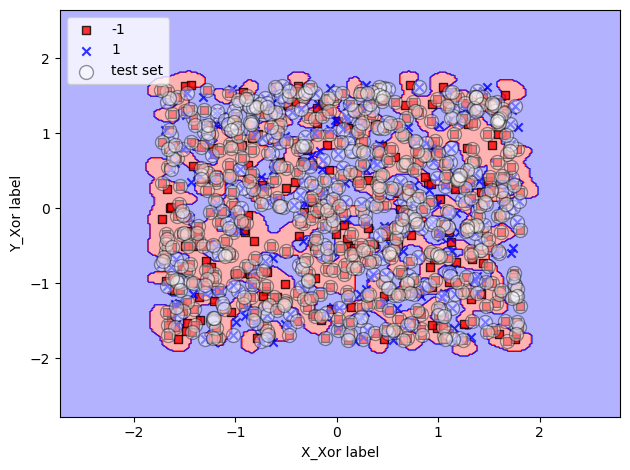

1.0

In [89]:
X_combined = np.vstack((X_train, X_test))
Y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, Y_combined, classifier=svm_clf, test_idx=range(300, 1000))
plt.xlabel('X_Xor label')
plt.ylabel('Y_Xor label')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()  
svm_clf.score(X_train, y_train)